<a href="https://colab.research.google.com/github/Harsh04i/Urine-Test_exp2/blob/main/reagent_pads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

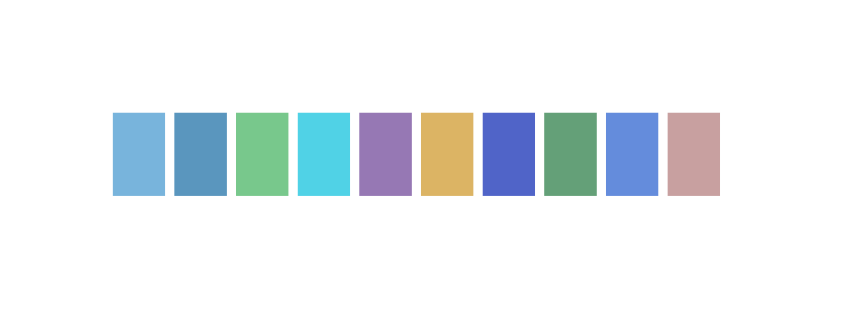

,Image,Pad,R_mean,G_mean,B_mean,R_std,G_std,B_std,R_min,G_min,B_min,R_max,G_max,B_max
0,urine_strip.jpg,1,120.0,180.0,220.0,0.0,0.0,0.0,120,180,220,120,180,220
1,urine_strip.jpg,2,90.0,150.0,190.0,0.0,0.0,0.0,90,150,190,90,150,190
2,urine_strip.jpg,3,120.0,200.0,140.0,0.0,0.0,0.0,120,200,140,120,200,140
3,urine_strip.jpg,4,80.0,210.0,230.0,0.0,0.0,0.0,80,210,230,80,210,230
4,urine_strip.jpg,5,150.0,120.0,180.0,0.0,0.0,0.0,150,120,180,150,120,180
5,urine_strip.jpg,6,220.0,180.0,100.0,0.0,0.0,0.0,220,180,100,220,180,100
6,urine_strip.jpg,7,80.0,100.0,200.0,0.0,0.0,0.0,80,100,200,80,100,200
7,urine_strip.jpg,8,100.0,160.0,120.0,0.0,0.0,0.0,100,160,120,100,160,120
8,urine_strip.jpg,9,100.0,140.0,220.0,0.0,0.0,0.0,100,140,220,100,140,220
9,urine_strip.jpg,10,200.0,160.0,160.0,0.0,0.0,0.0,200,160,160,200,160,160


CSV created successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install opencv-python-headless pandas matplotlib -q

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

img = np.ones((300,800,3), dtype=np.uint8) * 255

colors = [
    (220,180,120),
    (190,150,90),
    (140,200,120),
    (230,210,80),
    (180,120,150),
    (100,180,220),
    (200,100,80),
    (120,160,100),
    (220,140,100),
    (160,160,200)
]

x = 100

for c in colors:
    cv2.rectangle(img, (x,100), (x+50,180), c, -1)
    x += 60

image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,4))
plt.imshow(image)
plt.axis("off")
plt.show()


features = []

for i, x in enumerate(range(100,700,60)):

    pad = image[100:180, x:x+50]

    R = pad[:,:,0]
    G = pad[:,:,1]
    B = pad[:,:,2]

    features.append({
        "Image":"urine_strip.jpg",
        "Pad":i+1,

        "R_mean":round(np.mean(R),2),
        "G_mean":round(np.mean(G),2),
        "B_mean":round(np.mean(B),2),

        "R_std":round(np.std(R),2),
        "G_std":round(np.std(G),2),
        "B_std":round(np.std(B),2),

        "R_min":int(np.min(R)),
        "G_min":int(np.min(G)),
        "B_min":int(np.min(B)),

        "R_max":int(np.max(R)),
        "G_max":int(np.max(G)),
        "B_max":int(np.max(B))
    })


df = pd.DataFrame(features)

display(df)

df.to_csv("RGB_Features.csv", index=False)

print("CSV created successfully")

files.download("RGB_Features.csv")

In [8]:
import cv2

image = cv2.imread("strip.jpg")
image = cv2.resize(image, (600, 150))
blur = cv2.GaussianBlur(image, (5,5), 0)

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [6]:
pad1 = image[20:70, 40:90]
pad2 = image[20:70, 100:150]
pad3 = image[20:70, 160:210]

In [7]:
import cv2
import numpy as np

roi = pad1

mean_bgr = cv2.mean(roi)[:3]

blue = mean_bgr[0]
green = mean_bgr[1]
red = mean_bgr[2]

print(red, green, blue)

255.0 255.0 255.0


Saving ChatGPT Image Jul 20, 2026, 11_39_50 AM.png to ChatGPT Image Jul 20, 2026, 11_39_50 AM.png
Mean Red   : 222.23
Mean Green : 218.64
Mean Blue  : 211.94


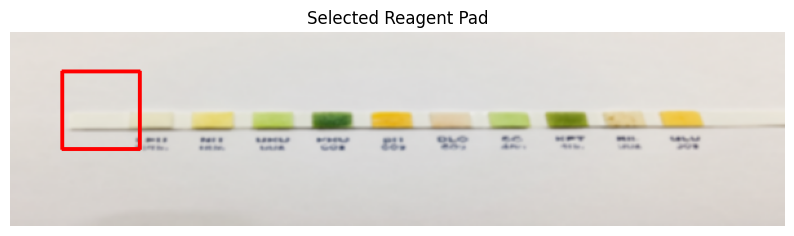

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (600, 150))
image = cv2.GaussianBlur(image, (5, 5), 0)

roi = image[30:90, 40:100]

mean_rgb = np.mean(roi, axis=(0, 1))

print("Mean Red   :", round(mean_rgb[0], 2))
print("Mean Green :", round(mean_rgb[1], 2))
print("Mean Blue  :", round(mean_rgb[2], 2))

display = image.copy()
cv2.rectangle(display, (40, 30), (100, 90), (255, 0, 0), 2)

plt.figure(figsize=(10, 5))
plt.imshow(display)
plt.title("Selected Reagent Pad")
plt.axis("off")
plt.show()